,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,Yes,0,Graduate,No,6000,2250.0,265.0,360.0,1.0,Semiurban,N
1,Male,Yes,0,Graduate,No,2958,2900.0,131.0,360.0,1.0,Semiurban,Y
2,Male,Yes,2,Graduate,No,6250,1695.0,210.0,360.0,1.0,Semiurban,Y
3,Male,Yes,0,Graduate,No,2083,3150.0,128.0,360.0,1.0,Semiurban,Y
4,Male,No,0,Graduate,No,4166,0.0,98.0,360.0,0.0,Semiurban,N


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,Loan_Status_Y
0,6000,2250.0,265.0,360.0,1.0,True,True,False,False,False,False,False,True,False,False
1,2958,2900.0,131.0,360.0,1.0,True,True,False,False,False,False,False,True,False,True
2,6250,1695.0,210.0,360.0,1.0,True,True,False,True,False,False,False,True,False,True
3,2083,3150.0,128.0,360.0,1.0,True,True,False,False,False,False,False,True,False,True
4,4166,0.0,98.0,360.0,0.0,True,False,False,False,False,False,False,True,False,False


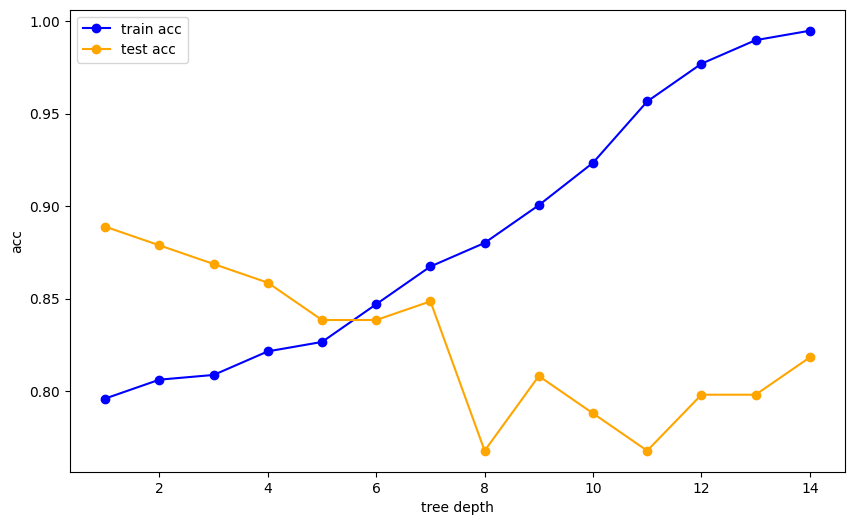

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree #학습된나무를그림으로보여줌
from IPython.display import display
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

loan_data = pd.read_csv('../datasets/decision/train_loan_80.csv')
display(loan_data.head())
loan_encoded = pd.get_dummies(loan_data, drop_first=True)
display(loan_encoded.head())
x = loan_encoded.drop(columns=['Loan_Status_Y'])
y = loan_encoded['Loan_Status_Y']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

depth_grids = range(1,15)
train_scr = []
test_scr = []
for d in depth_grids:
    dtree = DecisionTreeClassifier(max_depth = d, random_state=42)
    dtree.fit(x_train, y_train)
    train_scr.append(dtree.score(x_train, y_train))
    test_scr.append(dtree.score(x_test, y_test))
plt.figure(figsize = (10,6))
plt.plot(depth_grids, train_scr, label = 'train acc', marker='o', color='blue')
plt.plot(depth_grids, test_scr, label = 'test acc', marker='o', color='orange')
plt.xlabel('tree depth')
plt.ylabel('acc')
plt.legend()
plt.show()
